<a href="https://colab.research.google.com/github/pfs2-lab/rede-neural-duas-luas/blob/main/projeto_rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Rede Neural do Zero: Classificando as Duas Luas

**Especialização em Ciência de Dados · Matemática para Ciência de Dados**<br>
**Professor:** Adenilton<br>
**Aluno:** Paulo Fraga<br>
**Entrega:** 26/09/2026

---

## 🎯 Objetivo

Projetar e implementar uma rede neural a partir do `exemplo4.py` visto em aula, escrevendo **à mão**, apenas com NumPy, as três peças do aprendizado:

1. **Forward**: a rede calcula sua resposta
2. **Backpropagation**: a regra da cadeia calcula quanto cada peso contribuiu para o erro
3. **Gradiente descendente**: os pesos são ajustados na direção que reduz o erro

**Modificações em relação ao exemplo do professor:**

- Implementação na **forma matricial**, em vez de nó por nó
- **Mais neurônios** na camada oculta
- Ativação **tanh** na camada oculta, mantendo a **sigmoid** na saída

---

## 🗺️ Estrutura do notebook

| Seção | Conteúdo |
|---|---|
| **1. Seção didática: um neurônio, duas classes** | O ciclo completo de aprendizado com um único neurônio, em dados separáveis por uma reta |
| **2. Um neurônio nas duas luas** | O limite de um único neurônio quando os dados não são separáveis por uma reta |
| **3. Rede com camada oculta** | A implementação principal: mais neurônios e ativação tanh |
| **4. Experimentos e conclusões** | Comparação entre configurações e análise dos resultados |

> 📘 **Sobre a Seção 1:** antes de enfrentar as duas luas, esta seção fixa o contexto com o caso mais simples possível: **um único neurônio** separando **dois grupos** de pontos com uma reta. Nela, cada etapa é construída passo a passo e visualizada no plano: a reta definida pelos pesos e pelo bias, o forward, o erro, as derivadas descobertas por experimento e a atualização dos pesos. Assim, quando a rede completa aparecer, cada peça já terá um significado concreto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [2]:
# ===== Funções auxiliares =====

# Ativações e suas derivadas (em função da saída y)
def sigmoid(v):
    return 1 / (1 + np.exp(-v))

def d_sigmoid(y):
    return y * (1 - y)

def tanh(v):
    return np.tanh(v)

def d_tanh(y):
    return 1 - y**2


# Visualização de um neurônio: reta de decisão, regiões e um ponto destacado
def mostrar_neuronio(w, b, x, d, titulo='', Xd=None, Yd=None):
    if Xd is None:                       # por padrão, usa os dados da Seção 1
        Xd, Yd = Xs, Ys

    # grade cobrindo a região dos dados (com uma margem)
    x1_min, x1_max = Xd[:, 0].min() - 0.5, Xd[:, 0].max() + 0.5
    x2_min, x2_max = Xd[:, 1].min() - 0.5, Xd[:, 1].max() + 0.5
    x1g, x2g = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                           np.linspace(x2_min, x2_max, 200))

    yg = sigmoid(w[0]*x1g + w[1]*x2g + b)                  # saída do neurônio na grade
    plt.contourf(x1g, x2g, yg, levels=[0, 0.5, 1], cmap=plt.cm.Spectral, alpha=0.25)
    plt.contour(x1g, x2g, yg, levels=[0.5], colors='k')    # a reta (y = 0.5)

    plt.scatter(Xd[:, 0], Xd[:, 1], c=Yd, cmap=plt.cm.Spectral, alpha=0.6)

    y = sigmoid(w[0]*x[0] + w[1]*x[1] + b)
    prevista = 1 if y > 0.5 else 0
    acertou = prevista == d
    plt.scatter(x[0], x[1], s=400, marker='*', edgecolors='k',
                c='lime' if acertou else 'red',
                label=f'ponto escolhido: real={d}, previsto={prevista} ({"ACERTOU" if acertou else "ERROU"})')

    plt.title(titulo + f'   y = {y:.3f}')
    plt.xlabel('x1'); plt.ylabel('x2')
    plt.legend(loc='upper left')

---

# 1. Seção didática: um neurônio, duas classes

Nesta seção usamos dois grupos de pontos que **uma reta consegue separar**. O objetivo é acompanhar, com um único neurônio, o ciclo completo de aprendizado:

**pesos e bias aleatórios → forward → erro → backward → atualização → repetir**

Os pesos `w1`, `w2` e o bias `b` definem a reta `w1·x1 + w2·x2 + b = 0`. Treinar o neurônio é **mover essa reta** até que ela separe as duas classes.

### 1.1 Os dados: dois grupos separáveis

Geramos 100 pontos com `make_blobs`, em dois grupos centrados em (−2, −2) e (2, 2). Cada ponto tem duas coordenadas, `x1` (eixo horizontal) e `x2` (eixo vertical), e uma classe, 0 ou 1.

**O que observar:** existe uma reta que deixa cada grupo de um lado. Encontrar essa reta é exatamente o que o neurônio vai aprender a fazer.

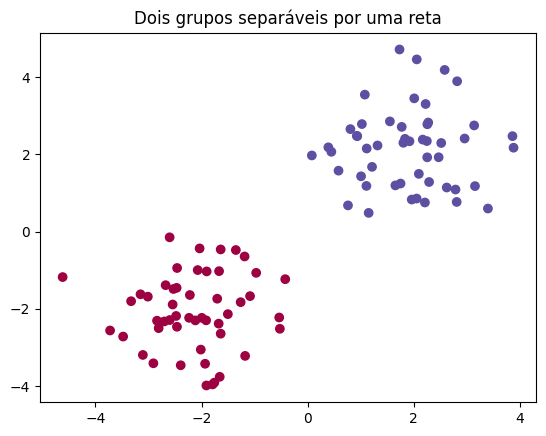

In [3]:
#Aquecimento, um neurônio separando dois grupos
samples = 100
Xs, Ys = datasets.make_blobs(n_samples=samples, centers=[(-2, -2), (2, 2)],
                             cluster_std=1.0, random_state=42)

plt.scatter(Xs[:, 0], Xs[:, 1], c=Ys, cmap=plt.cm.Spectral)
plt.title('Dois grupos separáveis por uma reta')
plt.show()

### 1.2 Forward com pesos aleatórios

Sorteamos `w1`, `w2` e `b`, que juntos definem uma reta qualquer no plano. Para cada ponto:

1. **soma ponderada:** `v = w1·x1 + w2·x2 + b`. O sinal de `v` diz de que lado da reta o ponto está.
2. **ativação:** `y = sigmoid(v)`, um número entre 0 e 1.
3. **classe prevista:** 1 se `y > 0.5`, 0 caso contrário.
4. **erro e loss:** `e = y − d` e `L = ½e²`, em que `d` é a classe verdadeira.

**O que observar:** com os pesos sorteados (seed 2), a reta fica longe dos grupos e o neurônio acerta só **50%** dos pontos, o mesmo que jogar uma moeda. A loss total é **24,3**.

In [4]:
np.random.seed(2)
w = np.random.randn(2)      # dois pesos aleatórios
b = np.random.randn()       # um bias aleatório
print('pesos iniciais:', w, ' bias:', b)

n = len(Xs)
acertos = 0
loss_total = 0

for k in range(n):
    x = Xs[k]
    d = Ys[k]
    v = w[0]*x[0] + w[1]*x[1] + b     # soma ponderada
    y = sigmoid(v)                    # ativação

    prevista = 1 if y > 0.5 else 0
    if prevista  == d:
        acertos += 1

    e = y - d
    loss_total += 0.5 * e**2


print('pontos:', n)
print('acertos:', acertos, f'({100*acertos/n:.0f}%)')
print('loss total:', loss_total)

pesos iniciais: [-0.41675785 -0.05626683]  bias: -2.136196095668454
pontos: 100
acertos: 50 (50%)
loss total: 24.335855500225833


### 1.3 O mesmo forward na forma matricial

A operação `Xs @ w + b` calcula o `v` de **todos os pontos de uma vez**. `Xs` tem formato (100, 2): cada linha é um ponto e cada coluna uma coordenada. O produto `@` com o vetor `w` faz a soma ponderada `w1·x1 + w2·x2` de cada linha e devolve 100 valores, um `v` por ponto.

Essa é a forma que será usada na rede completa: o que no `exemplo4.py` aparece nó por nó (`s00`, `s01`, `s02`...) vira uma única multiplicação de matrizes.

**O que observar:** a acurácia e a loss são **idênticas** às do laço da Seção 1.2.

In [5]:
V = Xs @ w + b          # v de TODOS os pontos de uma vez
Yp = sigmoid(V)         # y de todos os pontos
print(V.shape, Yp.shape)
print('acurácia:', np.mean((Yp > 0.5) == Ys))
print('loss total:', np.sum(0.5 * (Yp - Ys)**2))

(100,) (100,)
acurácia: 0.5
loss total: 24.335855500225836


### 1.4 Uma época: backward e atualização

Para cada ponto, a **regra da cadeia** dá quanto cada parâmetro contribuiu para o erro. Seguindo o caminho `w → v → y → e → L` e multiplicando as sensibilidades de cada trecho:

- `∂L/∂w1 = e · y(1−y) · x1`
- `∂L/∂w2 = e · y(1−y) · x2`
- `∂L/∂b = e · y(1−y) · 1`

Os fatores `x1`, `x2` e `1` são as derivadas de `v` em relação a cada parâmetro, descobertas por experimento: aumentar `w1` em 1 aumenta `v` em `x1`. Os gradientes de todos os pontos são somados e os parâmetros andam **contra** o gradiente: `w ← w − taxa · grad`. A célula sorteia os pesos no início, então **cada execução mostra sempre a época 1**.

**O que observar:** numa única época, a loss cai de 24,3 para 4,0 e a acurácia sobe de 50% para 87%. A reta sai do canto e vai para o espaço entre os grupos.

gradientes somados: [-9.41934075 -9.5761068 ] 0.23856601488682083
pesos novos: [0.52517623 0.90134385]  bias novo: -2.1600526971571363
acurácia: 0.87
loss total: 3.988088471069608


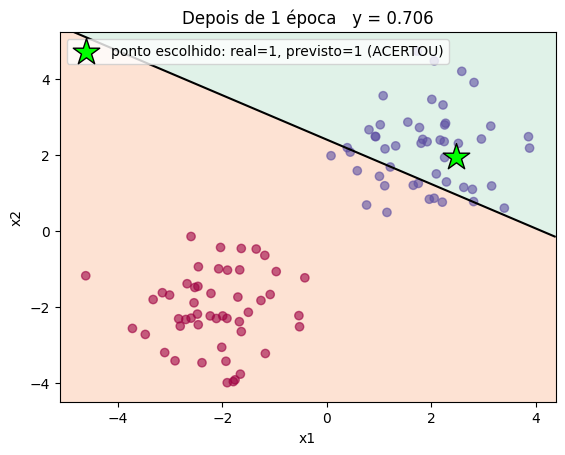

In [6]:
# Começa SEMPRE dos mesmos pesos aleatórios: cada execução desta célula é a época 1
np.random.seed(2)
w = np.random.randn(2)
b = np.random.randn()
n = len(Xs)

taxa = 0.1

grad_w = np.zeros(2)
grad_b = 0.0

for k in range(n):
    x = Xs[k]
    d = Ys[k]

    #forward
    v = w[0]*x[0] + w[1]*x[1] + b
    y = sigmoid(v)
    e = y - d

    #backward
    grad_v = e * y * (1 - y)
    grad_w[0] += grad_v * x[0]
    grad_w[1] += grad_v * x[1]
    grad_b += grad_v * 1

print('gradientes somados:', grad_w, grad_b)

# atualização: anda CONTRA o gradiente
w = w - taxa * grad_w
b = b - taxa * grad_b
print('pesos novos:', w, ' bias novo:', b)

# forward de novo, para ver se melhorou
Yp = sigmoid(Xs @ w + b)
print('acurácia:', np.mean((Yp > 0.5) == Ys))
print('loss total:', np.sum(0.5 * (Yp - Ys)**2))

mostrar_neuronio(w, b, Xs[0], Ys[0], 'Depois de 1 época')
plt.show()


### 1.5 Treinamento completo: muitas épocas

Repetimos a época da Seção 1.4 várias vezes, sempre a partir dos pesos atualizados, e guardamos a loss de cada época para desenhar a **curva de aprendizado**.

**O que observar:**

- A loss cai rápido no início e desacelera no final. O passo de cada atualização é `taxa × gradiente`, e o gradiente depende do tamanho dos erros: no começo os erros são grandes, e perto do mínimo são pequenos.
- A acurácia chega a **100%**: a reta termina separando os dois grupos.
- A loss não chega a zero, porque a sigmoid nunca dá exatamente 0 ou 1.
- **Taxa de aprendizado:** com taxas maiores a loss cai mais rápido; com taxas muito pequenas (0,001), 100 épocas não bastam. Taxa e número de épocas precisam ser escolhidos juntos.

época   0   loss = 24.3359   acurácia = 0.50
época  10   loss = 2.4056   acurácia = 0.98
época  20   loss = 0.8342   acurácia = 0.98
época  30   loss = 0.5136   acurácia = 1.00
época  40   loss = 0.3745   acurácia = 1.00
época  50   loss = 0.2960   acurácia = 1.00
época  60   loss = 0.2453   acurácia = 1.00
época  70   loss = 0.2097   acurácia = 1.00
época  80   loss = 0.1832   acurácia = 1.00
época  90   loss = 0.1628   acurácia = 1.00


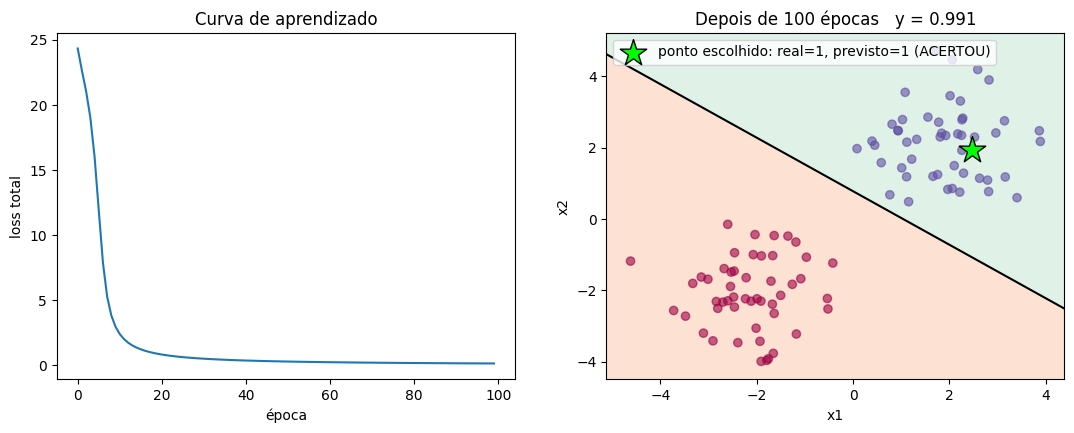

In [7]:
# recomeça dos pesos aleatórios, para ver o treino completo
np.random.seed(2)
w = np.random.randn(2)
b = np.random.randn()

taxa = 0.01
epocas = 100
historico_loss = []

for epoca in range(epocas):
    grad_w = np.zeros(2)
    grad_b = 0.0
    loss_total = 0

    for k in range(n):
        x = Xs[k]
        d = Ys[k]
        # forward
        v = w[0]*x[0] + w[1]*x[1] + b
        y = sigmoid(v)
        e = y - d
        loss_total += 0.5 * e**2
        # backward
        grad_v = e * y * (1 - y)
        grad_w[0] += grad_v * x[0]
        grad_w[1] += grad_v * x[1]
        grad_b    += grad_v * 1

    # atualização (uma vez por época)
    w = w - taxa * grad_w
    b = b - taxa * grad_b

    historico_loss.append(loss_total)
    if epoca % 10 == 0:
        acc = np.mean((sigmoid(Xs @ w + b) > 0.5) == Ys)
        print(f'época {epoca:3d}   loss = {loss_total:.4f}   acurácia = {acc:.2f}')

# gráficos lado a lado: curva da loss e reta final
plt.figure(figsize=(13, 4.5))

plt.subplot(1, 2, 1)
plt.plot(historico_loss)
plt.xlabel('época'); plt.ylabel('loss total')
plt.title('Curva de aprendizado')

plt.subplot(1, 2, 2)
mostrar_neuronio(w, b, Xs[0], Ys[0], f'Depois de {epocas} épocas')

plt.show()

---

# 🌙 2. Um neurônio nas duas luas

Agora saímos do caso fácil. Os dados formam duas **"luas" entrelaçadas**, e **nenhuma reta** consegue separar as duas classes perfeitamente.

**Base de dados utilizada:**

| Parâmetro | Exemplo do professor | Este trabalho |
|---|---|---|
| Pontos | 100 | **500** |
| Ruído (`noise`) | 0.1 | **0.2** |
| Divisão treino/teste | não há | **70% / 30%** (350 / 150 pontos) |

**Por que essas mudanças?**

- **Mais ruído:** as luas passam a se sobrepor um pouco, então alguns pontos ficam "do lado errado" e nenhum modelo deveria acertá-los. Isso torna o problema mais realista e permite observar quando a rede começa a **decorar o ruído** (overfitting).
- **Separação treino/teste:** o modelo aprende só com o treino e é avaliado em pontos que **nunca viu**. É a medida honesta de quanto ele generaliza.

> 🔎 **Objetivo desta seção:** treinar o mesmo neurônio da Seção 1 nessas luas e observar o seu **limite**. Como um único neurônio só consegue desenhar uma reta, esperamos que ela fique atravessando o meio das luas e erre as "pontas" de cada classe. Esse resultado é o ponto de partida que motiva a camada oculta da Seção 3.

### 2.1 Os dados: duas luas

Geramos 500 pontos com `make_moons` e `noise=0.2` e separamos **350 para treino** e **150 para teste**. O neurônio aprende só com o treino; o teste serve para medir o desempenho em pontos que ele nunca viu.

**O que observar:** as duas luas se encaixam uma na outra, e na região central alguns pontos se sobrepõem por causa do ruído. O conjunto de teste tem a mesma forma do treino.

(350, 2) (350,)
(150, 2) (150,)


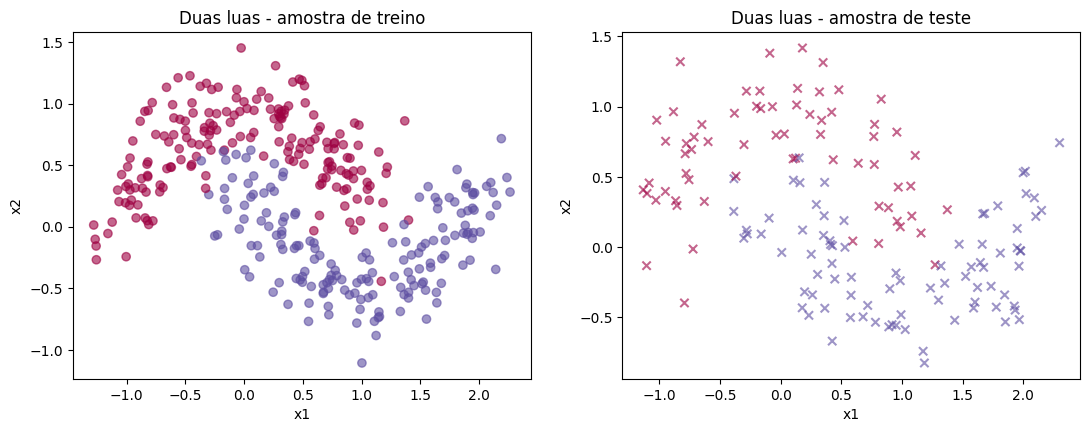

In [8]:
X, Y = datasets.make_moons(n_samples=500, noise=0.2, random_state=0)

X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size=0.3, random_state=0)

print(X_treino.shape, Y_treino.shape)
print(X_teste.shape, Y_teste.shape)

# treino e teste lado a lado
plt.figure(figsize=(13, 4.5))

plt.subplot(1, 2, 1)
plt.scatter(X_treino[:, 0], X_treino[:, 1], c=Y_treino, cmap=plt.cm.Spectral, marker='o', alpha=0.6)
plt.title('Duas luas - amostra de treino')
plt.xlabel('x1'); plt.ylabel('x2')

plt.subplot(1, 2, 2)
plt.scatter(X_teste[:, 0], X_teste[:, 1], c=Y_teste, cmap=plt.cm.Spectral, marker='x', alpha=0.6)
plt.title('Duas luas - amostra de teste')
plt.xlabel('x1'); plt.ylabel('x2')

plt.show()

### 2.2 Forward com pesos aleatórios nas luas

O mesmo forward da Seção 1.2, com os **mesmos pesos iniciais** (seed 2), agora aplicado aos 350 pontos de treino das luas: para cada ponto, `v = w1·x1 + w2·x2 + b` e `y = sigmoid(v)`.

**O que observar:** este é o ponto de partida do treino nas luas, com **53% de acerto** e **loss 72,0**. Com pesos aleatórios, o neurônio praticamente chuta.

In [9]:
np.random.seed(2)
w = np.random.randn(2)      # dois pesos aleatórios
b = np.random.randn()       # um bias aleatório
print('pesos iniciais:', w, ' bias:', b)

n = len(X_treino)
acertos = 0
loss_total = 0

for k in range(n):
    x = X_treino[k]
    d = Y_treino[k]
    v = w[0]*x[0] + w[1]*x[1] + b     # soma ponderada
    y = sigmoid(v)                    # ativação

    prevista = 1 if y > 0.5 else 0
    if prevista  == d:
        acertos += 1

    e = y - d
    loss_total += 0.5 * e**2


print('pontos:', n)
print('acertos:', acertos, f'({100*acertos/n:.0f}%)')
print('loss total:', loss_total)

pesos iniciais: [-0.41675785 -0.05626683]  bias: -2.136196095668454
pontos: 350
acertos: 184 (53%)
loss total: 72.02043363313635


### 2.3 Uma época de treino nas luas

O mesmo ciclo da Seção 1.4 (forward, erro, backward e atualização), agora com os 350 pontos de treino das luas. A célula sorteia os pesos no início, então **cada execução mostra sempre a época 1**.

**O que observar:** depois de uma única época, a loss cai de 72,0 para 41,0, mas a acurácia quase não muda (53% no treino, 44% no teste). A reta começa a se mover, mas ainda está longe das luas. Nas luas, uma época não basta: é preciso treinar por muitas épocas.

gradientes somados: [-9.39651191  2.6243433 ] -8.703800267445093
pesos novos: [ 0.52289334 -0.31870116]  bias novo: -1.2658160689239448
acurácia: 0.5257142857142857
loss total: 40.9953874737528
acurácia teste: 0.44


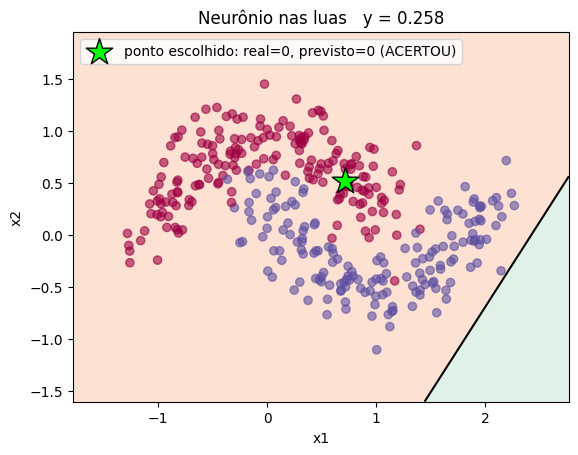

In [10]:
# Começa SEMPRE dos mesmos pesos aleatórios: cada execução desta célula é a época 1
np.random.seed(2)
w = np.random.randn(2)
b = np.random.randn()
n = len(X_treino)

taxa = 0.1

grad_w = np.zeros(2)
grad_b = 0.0

for k in range(n):
    x = X_treino[k]
    d = Y_treino[k]

    #forward
    v = w[0]*x[0] + w[1]*x[1] + b
    y = sigmoid(v)
    e = y - d

    #backward
    grad_v = e * y * (1 - y)
    grad_w[0] += grad_v * x[0]
    grad_w[1] += grad_v * x[1]
    grad_b += grad_v * 1

print('gradientes somados:', grad_w, grad_b)

# atualização: anda CONTRA o gradiente
w = w - taxa * grad_w
b = b - taxa * grad_b
print('pesos novos:', w, ' bias novo:', b)

# forward de novo, para ver se melhorou
Yp = sigmoid(X_treino @ w + b)
print('acurácia:', np.mean((Yp > 0.5) == Y_treino))
print('loss total:', np.sum(0.5 * (Yp - Y_treino)**2))

# desempenho em pontos que o neurônio NUNCA viu
Yp_teste = sigmoid(X_teste @ w + b)
print('acurácia teste:', np.mean((Yp_teste > 0.5) == Y_teste))

mostrar_neuronio(w, b, X_treino[0], Y_treino[0], 'Neurônio nas luas', X_treino, Y_treino)
plt.show()


### 2.4 Treinamento completo nas luas

O mesmo treino por épocas da Seção 1.5, agora com os 350 pontos de treino das luas. No final, medimos a acurácia no **treino** e no **teste**: o teste usa os pesos finais, sem backward, em 150 pontos que o neurônio nunca viu.

**O que observar:** a loss cai rápido nas primeiras épocas e depois quase para. A reta termina atravessando o meio das luas, como esperado, e erra as "pontas" de cada classe.

época   0   loss = 72.0204   acurácia = 0.53
época  10   loss = 26.4950   acurácia = 0.80
época  20   loss = 21.6684   acurácia = 0.81
época  30   loss = 19.6825   acurácia = 0.84
época  40   loss = 18.5069   acurácia = 0.85
época  50   loss = 17.7530   acurácia = 0.86
época  60   loss = 17.2440   acurácia = 0.87
época  70   loss = 16.8853   acurácia = 0.87
época  80   loss = 16.6230   acurácia = 0.87
época  90   loss = 16.4250   acurácia = 0.87


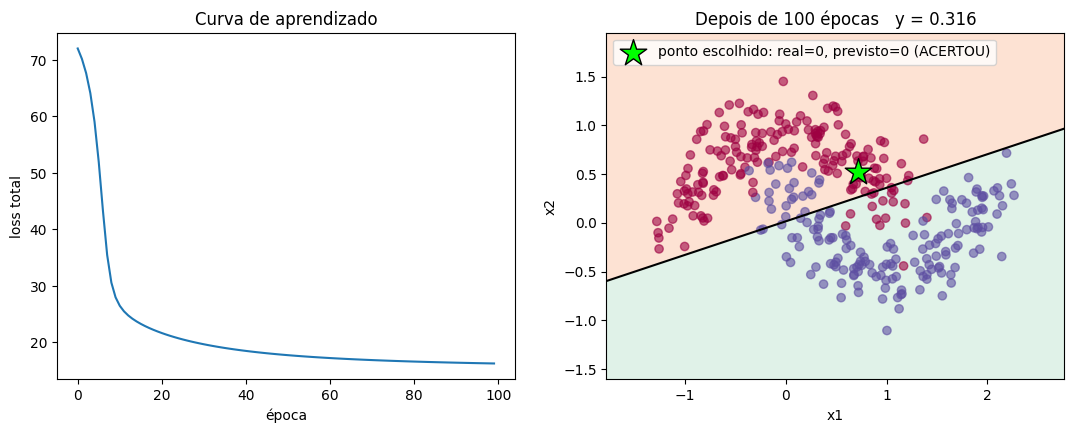

Um neurônio → acurácia treino: 0.88   teste: 0.83


In [11]:
# recomeça dos pesos aleatórios, para ver o treino completo
np.random.seed(2)
w = np.random.randn(2)
b = np.random.randn()

taxa = 0.01
epocas = 100
historico_loss = []
n = len(X_treino)

for epoca in range(epocas):
    grad_w = np.zeros(2)
    grad_b = 0.0
    loss_total = 0

    for k in range(n):
        x = X_treino[k]
        d = Y_treino[k]
        # forward
        v = w[0]*x[0] + w[1]*x[1] + b
        y = sigmoid(v)
        e = y - d
        loss_total += 0.5 * e**2
        # backward
        grad_v = e * y * (1 - y)
        grad_w[0] += grad_v * x[0]
        grad_w[1] += grad_v * x[1]
        grad_b    += grad_v * 1

    # atualização (uma vez por época)
    w = w - taxa * grad_w
    b = b - taxa * grad_b

    historico_loss.append(loss_total)
    if epoca % 10 == 0:
        acc = np.mean((sigmoid(X_treino @ w + b) > 0.5) == Y_treino)
        print(f'época {epoca:3d}   loss = {loss_total:.4f}   acurácia = {acc:.2f}')

# gráficos lado a lado: curva da loss e reta final
plt.figure(figsize=(13, 4.5))

plt.subplot(1, 2, 1)
plt.plot(historico_loss)
plt.xlabel('época'); plt.ylabel('loss total')
plt.title('Curva de aprendizado')

plt.subplot(1, 2, 2)
mostrar_neuronio(w, b, X_treino[0], Y_treino[0], f'Depois de {epocas} épocas', X_treino, Y_treino)

plt.show()

acc_treino = np.mean((sigmoid(X_treino @ w + b) > 0.5) == Y_treino)
acc_teste  = np.mean((sigmoid(X_teste  @ w + b) > 0.5) == Y_teste)
print(f'Um neurônio → acurácia treino: {acc_treino:.2f}   teste: {acc_teste:.2f}')


### ✅ Conclusão da Seção 2: o limite de um neurônio

| Modelo | Parâmetros | Acurácia treino | Acurácia teste |
|---|---|---|---|
| 1 neurônio (sigmoid) | 3 | **88%** | **83%** |

- O treino funciona: a loss cai de 72,0 para cerca de 16 e a reta vai para o meio das luas.
- Mas a curva de aprendizado **achata**, e a acurácia para em torno de 88%. Mais épocas não resolvem: **o problema não é falta de treino, é falta de capacidade**.
- Um único neurônio só consegue desenhar **uma reta**. Nas luas, qualquer reta erra as "pontas" de cada classe, que invadem o lado da outra.

> 💡 **Para ir além, a rede precisa de uma fronteira curva.** A ideia da Seção 3 é usar **vários neurônios** numa camada oculta, cada um desenhando a sua reta, e um neurônio de saída que **combina** essas retas numa curva.

---

# 🧩 3. Rede com camada oculta

Um neurônio só consegue desenhar uma reta. Para as luas, colocamos uma **camada oculta** no meio:

```
x1, x2  →  H neurônios ocultos (tanh)  →  1 neurônio de saída (sigmoid)  →  y
```

- Cada neurônio oculto recebe x1 e x2, tem 2 pesos e 1 bias, e desenha **a sua própria reta**.
- O neurônio de saída recebe as H respostas dos ocultos, tem H pesos e 1 bias, e **combina** essas retas numa fronteira curva.
- Com H = 2 e sigmoid, é a mesma rede do `exemplo4.py` (9 parâmetros).

### 3.1 Da conta neurônio por neurônio para matrizes

Colocamos os pesos de cada neurônio oculto numa **coluna** da matriz `W1`:

```
         neurônio 1   neurônio 2
W1 =  [     w1           w1'    ]   ← pesos ligados a x1
      [     w2           w2'    ]   ← pesos ligados a x2
b1 =  [     b            b'     ]
```

A célula calcula a resposta da rede para um ponto de dois jeitos: neurônio por neurônio (como no `exemplo4.py`) e com `x @ W1 + b1`.

**O que observar:** os dois resultados dão o mesmo número. A multiplicação de matrizes faz as contas de todos os neurônios de uma vez. Essa comparação também serviu para achar dois erros de índice na versão neurônio por neurônio.

In [12]:
np.random.seed(0)
W1 = np.random.randn(2, 2)    # coluna j = pesos do neurônio oculto j
b1 = np.random.randn(2)       # um bias por neurônio oculto
W2 = np.random.randn(2, 1)    # um peso para cada neurônio oculto
b2 = np.random.randn(1)       # bias do neurônio de saída

x = X_treino[0]

# ---- Forma escalar: neurônio por neurônio, como no exemplo4.py ----
v1 = W1[0, 0]*x[0] + W1[1, 0]*x[1] + b1[0]     # neurônio oculto 1 (coluna 0 de W1)
h1 = np.tanh(v1)
v2 = W1[0, 1]*x[0] + W1[1, 1]*x[1] + b1[1]     # neurônio oculto 2 (coluna 1 de W1)
h2 = np.tanh(v2)
v_saida = W2[0, 0]*h1 + W2[1, 0]*h2 + b2[0]    # neurônio de saída: u1·h1 + u2·h2 + c
y_escalar = sigmoid(v_saida)

# ---- Forma matricial ----
H = np.tanh(x @ W1 + b1)       # as duas saídas ocultas de uma vez
y_matricial = sigmoid(H @ W2 + b2)

print('escalar:  ', y_escalar)
print('matricial:', y_matricial)

escalar:   0.685329455937026
matricial: [0.68532946]


### 3.2 Forward de todos os pontos, com H neurônios

Trocamos `x` por `X_treino` (os 350 pontos de uma vez) e o tamanho 2 por `H_ocultos`. Formatos com H = 4:

| Variável | Formato | O que é |
|---|---|---|
| `V1 = X_treino @ W1 + b1` | (350, 4) | o v de cada neurônio oculto, para cada ponto |
| `H1 = tanh(V1)` | (350, 4) | a saída de cada neurônio oculto |
| `V2 = H1 @ W2 + b2` | (350, 1) | o v do neurônio de saída |
| `Y_pred = sigmoid(V2)` | (350, 1) | a resposta da rede |

**O que observar:** com pesos aleatórios a rede acerta ~47% (chute). São 17 parâmetros: 8 + 4 + 4 + 1. Como `Y_pred` é (350, 1) e `Y_treino` é (350,), usamos `Y_pred[:, 0]` para comparar.

In [13]:
H_ocultos = 4                               # número de neurônios na camada oculta

np.random.seed(0)
W1 = np.random.randn(2, H_ocultos)          # 2 entradas → H neurônios
b1 = np.random.randn(H_ocultos)
W2 = np.random.randn(H_ocultos, 1)          # H neurônios → 1 saída
b2 = np.random.randn(1)

# forward de todos os pontos
V1 = X_treino @ W1 + b1
H1 = np.tanh(V1)
V2 = H1 @ W2 + b2
Y_pred = sigmoid(V2)

print('V1:', V1.shape, '  H1:', H1.shape, '  V2:', V2.shape, '  Y_pred:', Y_pred.shape)
print('acurácia (pesos aleatórios):', np.mean((Y_pred[:, 0] > 0.5) == Y_treino))

V1: (350, 4)   H1: (350, 4)   V2: (350, 1)   Y_pred: (350, 1)
acurácia (pesos aleatórios): 0.4742857142857143


### 3.3 Backward da rede

O neurônio de saída é igual ao neurônio da Seção 1, só que a entrada dele é `h` e não `x`. A novidade é levar o erro de volta até a camada oculta.

Na conta da saída, `v = u1·h1 + u2·h2 + c`. Se `h1` aumenta 1, o `v` aumenta `u1`: é o mesmo raciocínio de "se w1 aumenta 1, v aumenta x1". Então o erro chega em cada `h` **multiplicado pelo peso de saída** daquele neurônio (no `exemplo4.py`: `grad_y0 = grad_v2 * w1[0]`).

O backward fica em 4 passos:

1. **erro na saída:** `grad_V2 = e · y(1 − y)`, igual à Seção 1
2. **pesos da saída:** `grad_W2 = H1.T @ grad_V2`, igual à Seção 1 com `h` no lugar de `x`
3. **erro volta para cada h:** `grad_H1 = grad_V2 @ W2.T`
4. **passa pela tanh e chega nos pesos ocultos:** `grad_V1 = grad_H1 · (1 − h²)` e `grad_W1 = X_treino.T @ grad_V1`

O `@` com a matriz transposta (`.T`) soma todos os pontos de uma vez: é o mesmo que o `grad_w += grad_v * x` dentro do laço da Seção 1.

**O que observar:** cada gradiente tem o mesmo formato do seu parâmetro.

In [14]:
# Forward e backward da rede em todos os pontos de treino (uma vez, sem atualizar os pesos)
np.random.seed(0)
W1 = np.random.randn(2, H_ocultos)
b1 = np.random.randn(H_ocultos)
W2 = np.random.randn(H_ocultos, 1)
b2 = np.random.randn(1)

D = Y_treino.reshape(-1, 1)     # rótulos como coluna (350, 1), no mesmo formato do Y_pred

# forward
V1 = X_treino @ W1 + b1
H1 = np.tanh(V1)
V2 = H1 @ W2 + b2
Y_pred = sigmoid(V2)
E = Y_pred - D
loss_total = np.sum(0.5 * E**2)

# backward
# passo 1: erro na saída, igual à Seção 1 → e · y(1 − y)
grad_V2 = E * Y_pred * (1 - Y_pred)

# passo 2: pesos da saída, igual à Seção 1, mas com h no lugar de x
grad_W2 = H1.T @ grad_V2
grad_b2 = np.sum(grad_V2, axis=0)

# passo 3: o erro volta para cada h, multiplicado pelo peso de saída
grad_H1 = grad_V2 @ W2.T

# passo 4: passa pela tanh (derivada 1 − h²) e chega nos pesos da camada oculta
grad_V1 = grad_H1 * (1 - H1**2)
grad_W1 = X_treino.T @ grad_V1
grad_b1 = np.sum(grad_V1, axis=0)

print('W1:', W1.shape, '  grad_W1:', grad_W1.shape)
print('b1:', b1.shape, '    grad_b1:', grad_b1.shape)
print('W2:', W2.shape, '  grad_W2:', grad_W2.shape)
print('b2:', b2.shape, '    grad_b2:', grad_b2.shape)
print('loss total:', loss_total)

W1: (2, 4)   grad_W1: (2, 4)
b1: (4,)     grad_b1: (4,)
W2: (4, 1)   grad_W2: (4, 1)
b2: (1,)     grad_b2: (1,)
loss total: 70.7961081319615


### 3.4 Conferindo o backward

Para ter certeza de que o backward está certo, repetimos o teste da Seção 1: mexemos um pouquinho (`h = 0.0001`) num peso, para mais e para menos, e medimos quanto a loss muda:

`derivada ≈ (loss com peso + h  −  loss com peso − h) / (2h)`

Fazemos isso para um peso e um bias de cada camada.

**O que observar:** o valor do backward e o valor numérico são iguais até a 6ª casa decimal.

In [15]:
# Verificação do gradiente: o mesmo teste "mexe um pouquinho e vê quanto muda" da Seção 1
def loss_rede(W1, b1, W2, b2):
    Y_pred = sigmoid(np.tanh(X_treino @ W1 + b1) @ W2 + b2)
    return np.sum(0.5 * (Y_pred - D)**2)

h = 0.0001

# peso W1[0, 0]
W1_mais = W1.copy();  W1_mais[0, 0] += h
W1_menos = W1.copy(); W1_menos[0, 0] -= h
numerico = (loss_rede(W1_mais, b1, W2, b2) - loss_rede(W1_menos, b1, W2, b2)) / (2 * h)
print(f'W1[0,0]   backward: {grad_W1[0, 0]:.6f}   numérico: {numerico:.6f}')

# bias b1[0]
b1_mais = b1.copy();  b1_mais[0] += h
b1_menos = b1.copy(); b1_menos[0] -= h
numerico = (loss_rede(W1, b1_mais, W2, b2) - loss_rede(W1, b1_menos, W2, b2)) / (2 * h)
print(f'b1[0]     backward: {grad_b1[0]:.6f}   numérico: {numerico:.6f}')

# peso W2[0, 0]
W2_mais = W2.copy();  W2_mais[0, 0] += h
W2_menos = W2.copy(); W2_menos[0, 0] -= h
numerico = (loss_rede(W1, b1, W2_mais, b2) - loss_rede(W1, b1, W2_menos, b2)) / (2 * h)
print(f'W2[0,0]   backward: {grad_W2[0, 0]:.6f}   numérico: {numerico:.6f}')

# bias b2
b2_mais = b2.copy();  b2_mais[0] += h
b2_menos = b2.copy(); b2_menos[0] -= h
numerico = (loss_rede(W1, b1, W2, b2_mais) - loss_rede(W1, b1, W2, b2_menos)) / (2 * h)
print(f'b2        backward: {grad_b2[0]:.6f}   numérico: {numerico:.6f}')

W1[0,0]   backward: -2.531594   numérico: -2.531594
b1[0]     backward: 3.475741   numérico: 3.475741
W2[0,0]   backward: 1.586028   numérico: 1.586028
b2        backward: 13.020033   numérico: 13.020033


### 3.5 Treinando a rede

O mesmo treino da Seção 2.4, agora com a rede inteira: **forward → erro → backward → atualização**, por 5000 épocas com taxa 0,01. Aqui também criamos duas funções: `acuracia_rede`, para medir o acerto, e `mostrar_rede`, parecida com a `mostrar_neuronio`.

**O que observar:**

- A rede 2-4-1 chega a **99% no treino e 95% no teste**, contra 88% / 83% de um neurônio sozinho.
- No gráfico, as linhas tracejadas são as retas de cada neurônio oculto e a linha preta é a fronteira da rede. A fronteira é curva e acompanha as luas: ela sai da **combinação** dessas retas.

época    0   loss = 70.7961   acurácia = 0.49
época  500   loss = 3.9613   acurácia = 0.97
época 1000   loss = 3.3939   acurácia = 0.98
época 1500   loss = 3.2494   acurácia = 0.98
época 2000   loss = 3.1691   acurácia = 0.98
época 2500   loss = 3.1066   acurácia = 0.98
época 3000   loss = 3.0508   acurácia = 0.98
época 3500   loss = 2.9966   acurácia = 0.98
época 4000   loss = 2.9417   acurácia = 0.98
época 4500   loss = 2.8866   acurácia = 0.98


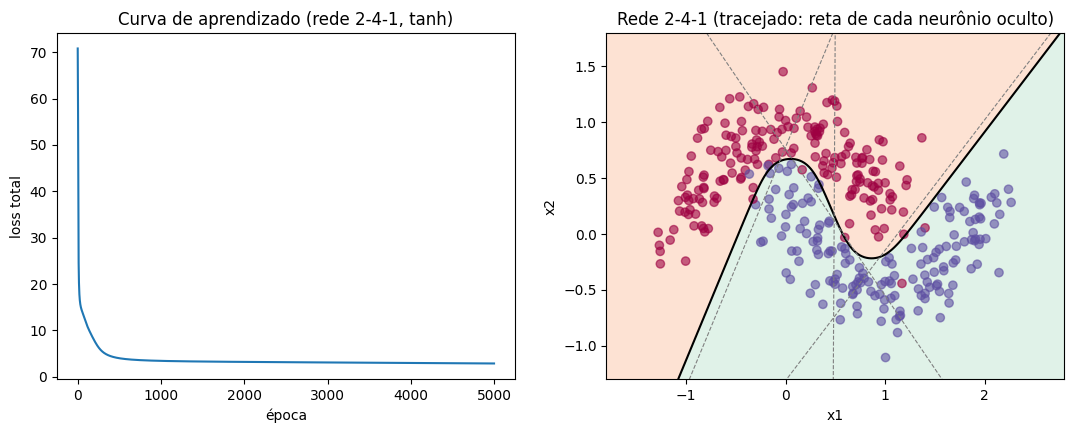

Rede 2-4-1 → acurácia treino: 0.99   teste: 0.95


In [16]:
# Funções para medir e desenhar a rede
def acuracia_rede(W1, b1, W2, b2, X, Y, ativacao='tanh'):
    V1 = X @ W1 + b1
    if ativacao == 'tanh':
        H1 = np.tanh(V1)
    else:
        H1 = sigmoid(V1)
    Y_pred = sigmoid(H1 @ W2 + b2)
    return np.mean((Y_pred[:, 0] > 0.5) == Y)


def mostrar_rede(W1, b1, W2, b2, titulo='', ativacao='tanh'):
    # grade cobrindo a região dos dados
    x1g, x2g = np.meshgrid(np.linspace(-1.8, 2.8, 200), np.linspace(-1.3, 1.8, 200))
    grade = np.column_stack([x1g.ravel(), x2g.ravel()])

    # resposta da rede em cada ponto da grade
    V1 = grade @ W1 + b1
    if ativacao == 'tanh':
        H1 = np.tanh(V1)
    else:
        H1 = sigmoid(V1)
    yg = sigmoid(H1 @ W2 + b2).reshape(x1g.shape)

    plt.contourf(x1g, x2g, yg, levels=[0, 0.5, 1], cmap=plt.cm.Spectral, alpha=0.25)
    plt.contour(x1g, x2g, yg, levels=[0.5], colors='k')       # fronteira da rede

    # a reta de cada neurônio oculto (tracejada)
    x1_linha = np.linspace(-1.8, 2.8, 100)
    for j in range(W1.shape[1]):
        x2_linha = -(W1[0, j] * x1_linha + b1[j]) / W1[1, j]
        plt.plot(x1_linha, x2_linha, '--', color='gray', lw=0.8)

    plt.scatter(X_treino[:, 0], X_treino[:, 1], c=Y_treino, cmap=plt.cm.Spectral, alpha=0.6)
    plt.xlim(-1.8, 2.8); plt.ylim(-1.3, 1.8)
    plt.title(titulo)
    plt.xlabel('x1'); plt.ylabel('x2')


# Treino da rede 2-4-1 com tanh
H_ocultos = 4
taxa = 0.01
epocas = 5000

np.random.seed(0)
W1 = np.random.randn(2, H_ocultos)
b1 = np.random.randn(H_ocultos)
W2 = np.random.randn(H_ocultos, 1)
b2 = np.random.randn(1)
historico_loss = []

for epoca in range(epocas):
    # forward
    V1 = X_treino @ W1 + b1
    H1 = np.tanh(V1)
    V2 = H1 @ W2 + b2
    Y_pred = sigmoid(V2)
    E = Y_pred - D
    loss_total = np.sum(0.5 * E**2)

    # backward
    grad_V2 = E * Y_pred * (1 - Y_pred)
    grad_W2 = H1.T @ grad_V2
    grad_b2 = np.sum(grad_V2, axis=0)
    grad_H1 = grad_V2 @ W2.T
    grad_V1 = grad_H1 * (1 - H1**2)
    grad_W1 = X_treino.T @ grad_V1
    grad_b1 = np.sum(grad_V1, axis=0)

    # atualização: anda CONTRA o gradiente
    W1 = W1 - taxa * grad_W1
    b1 = b1 - taxa * grad_b1
    W2 = W2 - taxa * grad_W2
    b2 = b2 - taxa * grad_b2

    historico_loss.append(loss_total)
    if epoca % 500 == 0:
        acc = acuracia_rede(W1, b1, W2, b2, X_treino, Y_treino)
        print(f'época {epoca:4d}   loss = {loss_total:.4f}   acurácia = {acc:.2f}')

# gráficos lado a lado: curva da loss e fronteira da rede
plt.figure(figsize=(13, 4.5))

plt.subplot(1, 2, 1)
plt.plot(historico_loss)
plt.xlabel('época'); plt.ylabel('loss total')
plt.title('Curva de aprendizado (rede 2-4-1, tanh)')

plt.subplot(1, 2, 2)
mostrar_rede(W1, b1, W2, b2, 'Rede 2-4-1 (tracejado: reta de cada neurônio oculto)')

plt.show()

acc_treino_rede = acuracia_rede(W1, b1, W2, b2, X_treino, Y_treino)
acc_teste_rede = acuracia_rede(W1, b1, W2, b2, X_teste, Y_teste)
print(f'Rede 2-4-1 → acurácia treino: {acc_treino_rede:.2f}   teste: {acc_teste_rede:.2f}')

---

# 🔬 4. Experimentos e conclusões

### 4.1 Número de neurônios e função de ativação

Colocamos o treino da Seção 3.5 dentro da função `treinar_rede` e testamos H = 2, 4, 8 e 16 neurônios ocultos, com tanh ou sigmoid na camada oculta. Cada configuração é treinada 5 vezes, com seeds diferentes, e a tabela mostra a média. Assim o resultado não depende da sorte dos pesos iniciais.

> ⏱️ Esta célula treina 40 redes e leva cerca de 1 minuto.

In [17]:
# O mesmo treino da Seção 3.5, dentro de uma função, para repetir com outros valores
def treinar_rede(H_ocultos, ativacao, seed, taxa=0.01, epocas=5000):
    np.random.seed(seed)
    W1 = np.random.randn(2, H_ocultos)
    b1 = np.random.randn(H_ocultos)
    W2 = np.random.randn(H_ocultos, 1)
    b2 = np.random.randn(1)
    historico_loss = []

    for epoca in range(epocas):
        # forward
        V1 = X_treino @ W1 + b1
        if ativacao == 'tanh':
            H1 = np.tanh(V1)
        else:
            H1 = sigmoid(V1)
        Y_pred = sigmoid(H1 @ W2 + b2)
        E = Y_pred - D
        historico_loss.append(np.sum(0.5 * E**2))

        # backward
        grad_V2 = E * Y_pred * (1 - Y_pred)
        grad_W2 = H1.T @ grad_V2
        grad_b2 = np.sum(grad_V2, axis=0)
        grad_H1 = grad_V2 @ W2.T
        if ativacao == 'tanh':
            grad_V1 = grad_H1 * (1 - H1**2)          # derivada da tanh
        else:
            grad_V1 = grad_H1 * H1 * (1 - H1)        # derivada da sigmoid
        grad_W1 = X_treino.T @ grad_V1
        grad_b1 = np.sum(grad_V1, axis=0)

        # atualização
        W1 = W1 - taxa * grad_W1
        b1 = b1 - taxa * grad_b1
        W2 = W2 - taxa * grad_W2
        b2 = b2 - taxa * grad_b2

    return W1, b1, W2, b2, historico_loss


# Cada configuração é treinada 5 vezes (seeds 0 a 4) e mostramos a média
print(f'{"rede":12s} {"ativação":10s} {"treino":>8s} {"teste":>8s} {"loss época 1000":>17s}')
print(f'{"1 neurônio":12s} {"-":10s} {acc_treino:8.3f} {acc_teste:8.3f} {"-":>17s}')

for ativacao in ['tanh', 'sigmoid']:
    for H_ocultos in [2, 4, 8, 16]:
        lista_treino = []
        lista_teste = []
        lista_loss = []
        for seed in range(5):
            W1, b1, W2, b2, historico_loss = treinar_rede(H_ocultos, ativacao, seed)
            lista_treino.append(acuracia_rede(W1, b1, W2, b2, X_treino, Y_treino, ativacao))
            lista_teste.append(acuracia_rede(W1, b1, W2, b2, X_teste, Y_teste, ativacao))
            lista_loss.append(historico_loss[999])
        rede = f'2-{H_ocultos}-1'
        print(f'{rede:12s} {ativacao:10s} {np.mean(lista_treino):8.3f} {np.mean(lista_teste):8.3f} '
              f'{np.mean(lista_loss):17.2f}')

rede         ativação     treino    teste   loss época 1000
1 neurônio   -             0.883    0.833                 -
2-2-1        tanh          0.898    0.865             13.68
2-4-1        tanh          0.982    0.945              3.58
2-8-1        tanh          0.983    0.953              3.38
2-16-1       tanh          0.986    0.956              3.45
2-2-1        sigmoid       0.892    0.851             14.94
2-4-1        sigmoid       0.959    0.920             12.81
2-8-1        sigmoid       0.977    0.945              7.23
2-16-1       sigmoid       0.975    0.949              7.09


### 4.2 A fronteira para cada número de neurônios

Mesma seed, mesma taxa e mesmas épocas. Só muda H.

**O que observar:**

- **H = 2:** só duas retas para combinar. A fronteira não acompanha as luas (~87% no teste). É o tamanho da rede do `exemplo4.py`.
- **H = 4:** a fronteira já faz o "S" entre as luas, e o teste sobe para ~95%.
- **H = 8 e 16:** a fronteira fica mais detalhada, mas o ganho é pequeno. Os pontos que continuam errados estão onde as luas se misturam por causa do ruído.

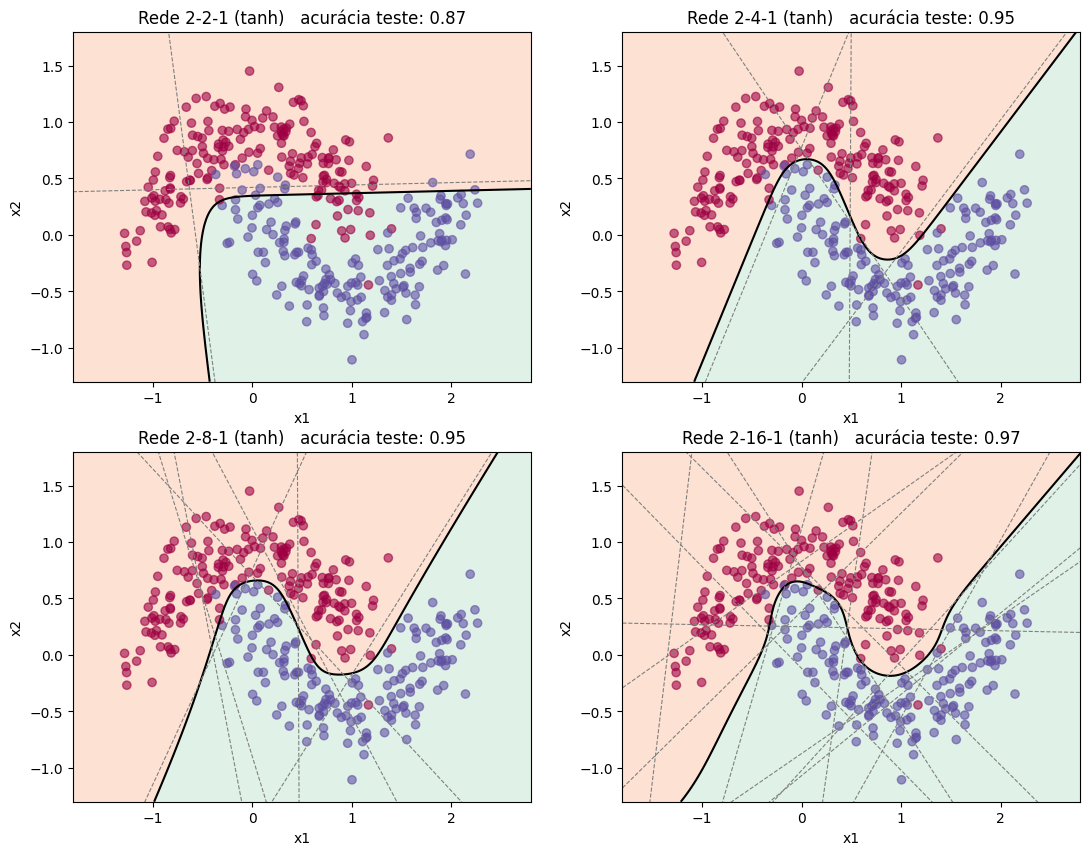

In [18]:
# Fronteira da rede para cada número de neurônios ocultos (tanh, seed 0), numa grade 2 x 2
plt.figure(figsize=(13, 10))

posicao = 1
for H_ocultos in [2, 4, 8, 16]:
    W1, b1, W2, b2, historico_loss = treinar_rede(H_ocultos, 'tanh', seed=0)
    acc = acuracia_rede(W1, b1, W2, b2, X_teste, Y_teste)

    plt.subplot(2, 2, posicao)
    mostrar_rede(W1, b1, W2, b2, f'Rede 2-{H_ocultos}-1 (tanh)   acurácia teste: {acc:.2f}')
    posicao += 1

plt.show()

### 4.3 tanh × sigmoid na camada oculta

Mesma rede (2-8-1) e mesma seed. Só muda a ativação dos neurônios ocultos.

**O que observar:**

- Com tanh, a loss cai bem mais rápido. Na tabela da 4.1, a loss na época 1000 é ~3,4 com tanh e ~7,2 com sigmoid.
- É o que vimos nas derivadas: a derivada da tanh chega a 1, a da sigmoid só a 0,25. No passo 4 do backward, o erro é multiplicado por essa derivada. Com sigmoid, o sinal que chega nos pesos ocultos fica até 4 vezes menor, e a rede aprende mais devagar.
- No final as fronteiras ficam parecidas, mas a sigmoid variou mais entre as seeds (com H = 4, teste médio de 92%, contra 94,5% com tanh).

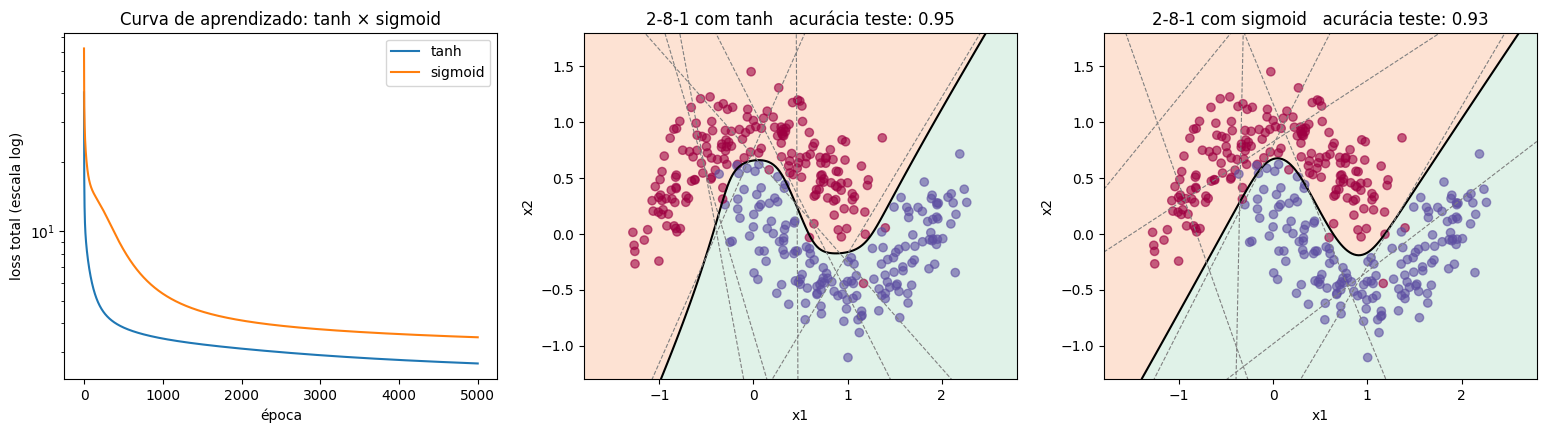

In [19]:
# tanh × sigmoid: mesma rede 2-8-1, mesma seed, só muda a ativação da camada oculta
W1_t, b1_t, W2_t, b2_t, loss_tanh = treinar_rede(8, 'tanh', seed=0)
W1_s, b1_s, W2_s, b2_s, loss_sigmoid = treinar_rede(8, 'sigmoid', seed=0)

acc_t = acuracia_rede(W1_t, b1_t, W2_t, b2_t, X_teste, Y_teste, 'tanh')
acc_s = acuracia_rede(W1_s, b1_s, W2_s, b2_s, X_teste, Y_teste, 'sigmoid')

# três gráficos lado a lado: as duas curvas de loss e as duas fronteiras
plt.figure(figsize=(19, 4.5))

plt.subplot(1, 3, 1)
plt.plot(loss_tanh, label='tanh')
plt.plot(loss_sigmoid, label='sigmoid')
plt.yscale('log')
plt.xlabel('época'); plt.ylabel('loss total (escala log)')
plt.title('Curva de aprendizado: tanh × sigmoid')
plt.legend()

plt.subplot(1, 3, 2)
mostrar_rede(W1_t, b1_t, W2_t, b2_t, f'2-8-1 com tanh   acurácia teste: {acc_t:.2f}', 'tanh')

plt.subplot(1, 3, 3)
mostrar_rede(W1_s, b1_s, W2_s, b2_s, f'2-8-1 com sigmoid   acurácia teste: {acc_s:.2f}', 'sigmoid')

plt.show()

### ✅ 4.4 Conclusões

| Modelo | Parâmetros | Treino | Teste |
|---|---|---|---|
| 1 neurônio (Seção 2) | 3 | 88% | 83% |
| 2-2-1, tanh (tamanho do `exemplo4.py`) | 9 | 90% | 87% |
| **2-4-1, tanh** | **17** | **98%** | **94,5%** |
| 2-8-1, tanh | 33 | 98% | 95% |
| 2-16-1, tanh | 65 | 99% | 96% |
| 2-8-1, sigmoid | 33 | 98% | 94,5% |

*Redes com camada oculta: média de 5 seeds.*

1. **Um neurônio desenha uma reta.** Nas luas ele para em ~88%. Não é falta de treino, é falta de capacidade.
2. **A camada oculta resolve.** Cada neurônio oculto é uma reta, e a saída combina essas retas numa curva. Com 4 neurônios, o teste sobe de 83% para ~95%.
3. **Mais neurônios ajudam até certo ponto.** De 2 para 4 o ganho é grande. De 4 para 16 é pequeno, porque o erro que sobra vem do ruído. A diferença entre treino e teste ficou em ~3 pontos, sem sinal forte de overfitting.
4. **A tanh aprende mais rápido que a sigmoid**, porque a derivada dela é maior (até 1, contra 0,25).
5. **O código está certo:** a forma matricial dá o mesmo resultado que a conta neurônio por neurônio (3.1), e o backward bate com a derivada numérica (3.4).

**O principal aprendizado:** o backpropagation é a regra da cadeia aplicada de trás para frente. Numa rede maior a ideia é a mesma; só mudam os formatos das matrizes.